<h1> Geometric Operations and Other Mathematical Tools with Pillow</h1>


Estimated time needed: **40** minutes


<h2> Spatial Operations in Image Processing</h2>


Spatial operations use  pixels in a neighborhood to determine the present pixel value. Some applications include filtering and sharpening. They are used in many steps in computer vision, such as segmentation, and are a key building block in Artificial Intelligence algorithms.


- Linear Filtering
    - Filtering Noise
    - Gaussian Blur
    - Image Sharpening
- Edges
- Median


* * *


In [10]:
import urllib.request

urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg", "cameraman.jpeg")
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png", "lenna.png")
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png", "barbara.png")

('barbara.png', <http.client.HTTPMessage at 0x1f21618ee40>)

Đoạn code này tải xuống các hình ảnh cần thiết cho bài lab.

In [11]:
# Used to view the images
import matplotlib.pyplot as plt
# Used to load an image
from PIL import Image
# Used to create kernels for filtering
import numpy as np

Đoạn code này nhập các thư viện cần thiết để xử lý hình ảnh và vẽ đồ thị.

In [12]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1)
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2)
    plt.title(title_2)
    plt.show()

Đoạn code này định nghĩa hàm để vẽ hai hình ảnh cạnh nhau để so sánh.

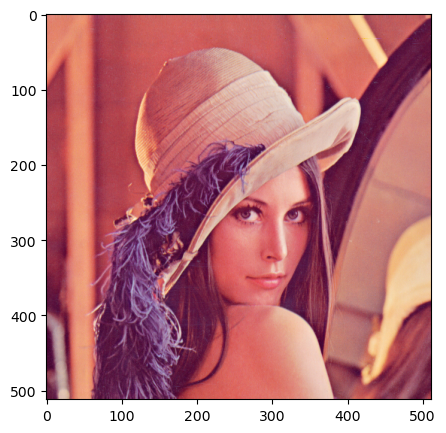

In [13]:
# Loads the image from the specified file
image = Image.open("lenna.png")
# Renders the image
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.show()

Đoạn code này tải hình ảnh lenna.png và hiển thị nó.

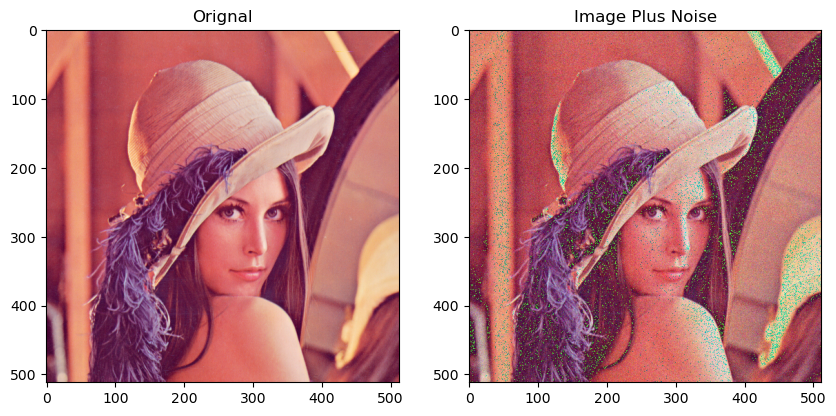

In [14]:
# Get the number of rows and columns in the image
rows, cols = image.size
# Creates values using a normal distribution with a mean of 0 and standard deviation of 15, the values are converted to unit8 which means the values are between 0 and 255
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8)
# Add the noise to the image
noisy_image = image + noise
# Creates a PIL Image from an array
noisy_image = Image.fromarray(noisy_image)
# Plots the original image and the image with noise using the function defined at the top
plot_image(image, noisy_image, title_1="Orignal", title_2="Image Plus Noise")

Đoạn code này thêm nhiễu ngẫu nhiên vào hình ảnh để mô phỏng hình ảnh có nhiễu.

In [15]:
from PIL import ImageFilter

Đoạn code này nhập module ImageFilter từ PIL để thực hiện các thao tác lọc.

In [16]:
# Create a kernel which is a 5 by 5 array where each value is 1/36
kernel = np.ones((5,5))/36
# Create a ImageFilter Kernel by providing the kernel size and a flattened kernel
kernel_filter = ImageFilter.Kernel((5,5), kernel.flatten())

Đoạn code này tạo kernel lọc trung bình 5x5.

In [17]:
# Filters the images using the kernel
image_filtered = noisy_image.filter(kernel_filter)

Đoạn code này áp dụng bộ lọc trung bình cho hình ảnh có nhiễu.

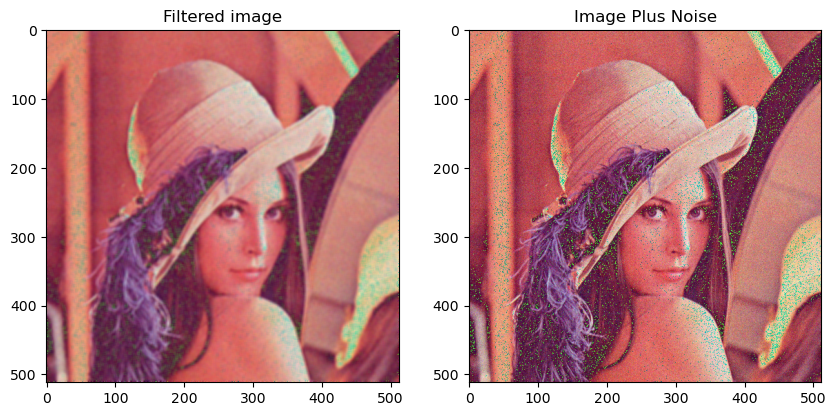

In [18]:
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Đoạn code này vẽ hình ảnh đã lọc và hình ảnh có nhiễu cạnh nhau.

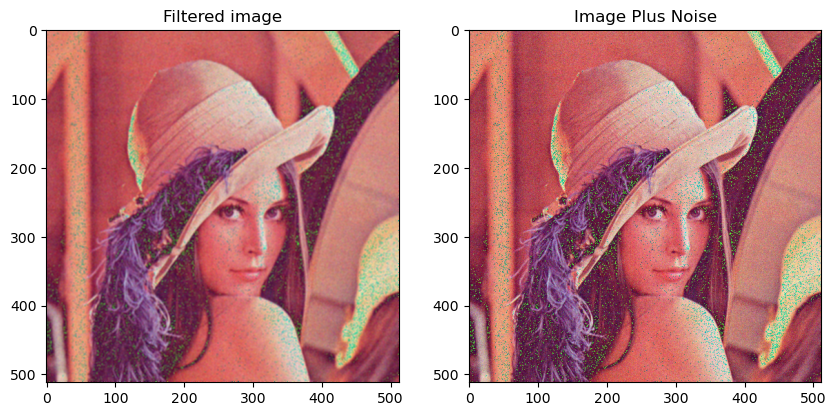

In [19]:
# Create a kernel which is a 3 by 3 array where each value is 1/36
kernel = np.ones((3,3))/36
# Create a ImageFilter Kernel by providing the kernel size and a flattened kernel
kernel_filter = ImageFilter.Kernel((3,3), kernel.flatten())
# Filters the images using the kernel
image_filtered = noisy_image.filter(kernel_filter)
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Đoạn code này tạo kernel lọc trung bình 3x3 và áp dụng nó, sau đó vẽ kết quả.

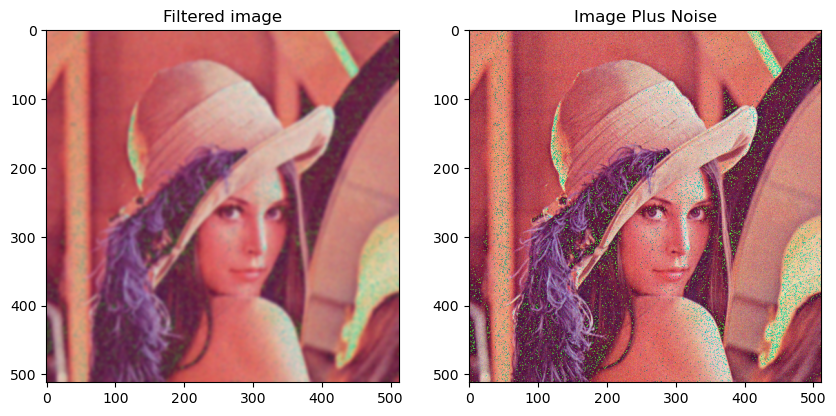

In [20]:
# Filters the images using GaussianBlur
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur)
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Đoạn code này áp dụng làm mờ Gaussian cho hình ảnh có nhiễu.

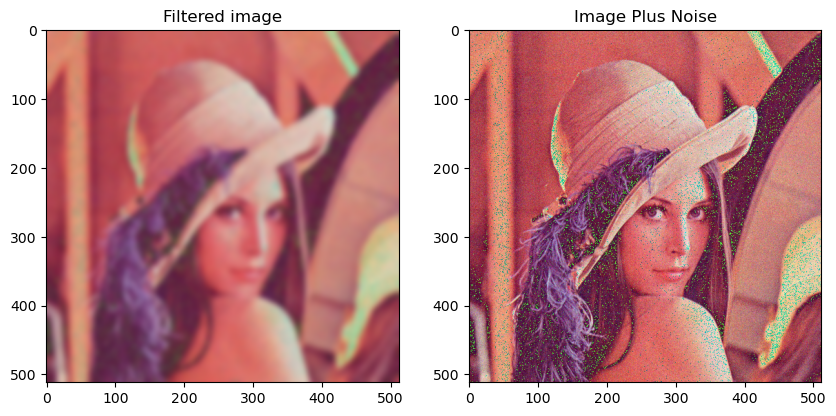

In [21]:
# Filters the images using GaussianBlur on the image with noise using a 4 by 4 kernel 
image_filtered = noisy_image.filter(ImageFilter.GaussianBlur(4))
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Đoạn code này áp dụng làm mờ Gaussian với bán kính 4 cho hình ảnh có nhiễu.

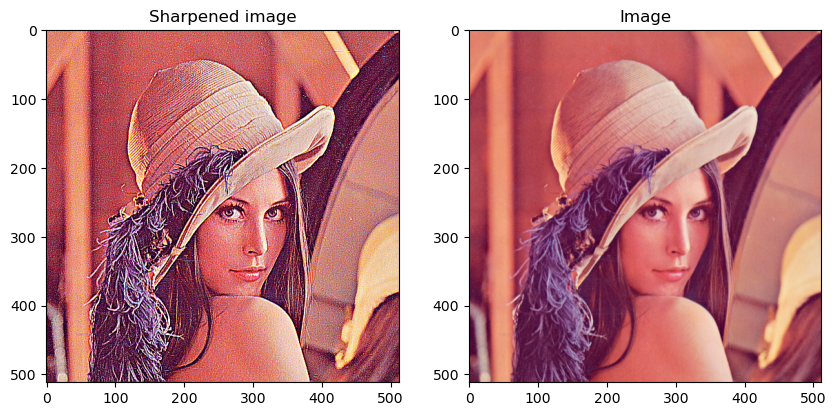

In [22]:
# Common Kernel for image sharpening
kernel = np.array([[-1,-1,-1], 
                   [-1, 9,-1],
                   [-1,-1,-1]])
kernel = ImageFilter.Kernel((3,3), kernel.flatten())
# Applys the sharpening filter using kernel on the original image without noise
sharpened = image.filter(kernel)
# Plots the sharpened image and the original image without noise
plot_image(sharpened , image, title_1="Sharpened image",title_2="Image")

Đoạn code này áp dụng bộ lọc làm sắc nét bằng kernel tùy chỉnh cho hình ảnh gốc.

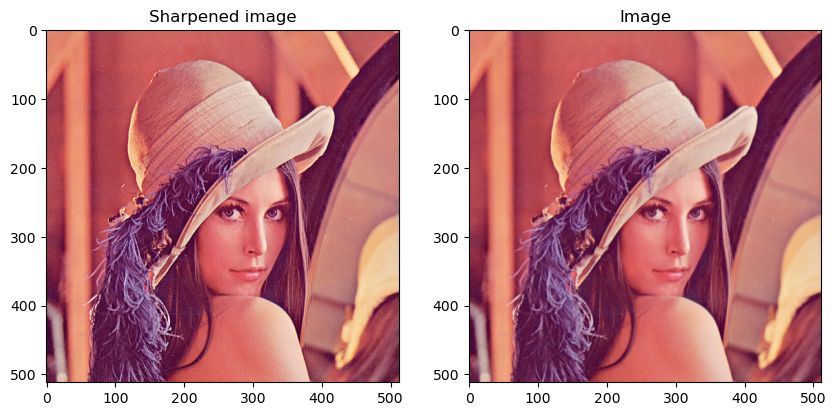

In [23]:
# Sharpends image using predefined image filter from PIL
sharpened = image.filter(ImageFilter.SHARPEN)
# Plots the sharpened image and the original image without noise
plot_image(sharpened , image, title_1="Sharpened image",title_2="Image")

Đoạn code này áp dụng bộ lọc làm sắc nét được định nghĩa sẵn cho hình ảnh gốc.

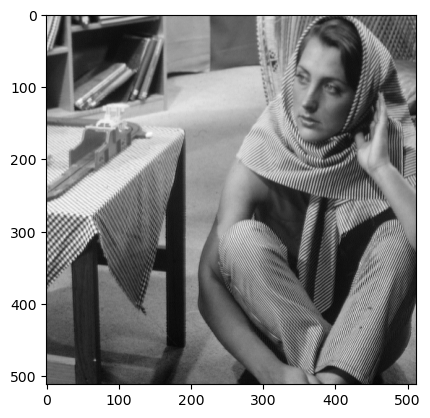

In [24]:
# Loads the image from the specified file
img_gray = Image.open('barbara.png')
# Renders the image from the array of data, notice how it is 2 diemensional instead of 3 diemensional because it has no color
plt.imshow(img_gray ,cmap='gray')

Đoạn code này tải hình ảnh barbara.png và hiển thị nó ở thang độ xám.

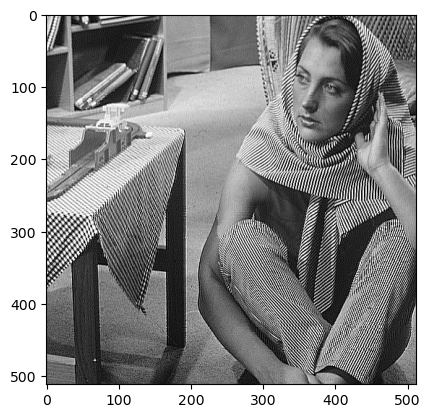

In [25]:
# Filters the images using EDGE_ENHANCE filter
img_gray = img_gray.filter(ImageFilter.EDGE_ENHANCE)
# Renders the enhanced image
plt.imshow(img_gray ,cmap='gray')

Đoạn code này tăng cường các cạnh trong hình ảnh thang độ xám.

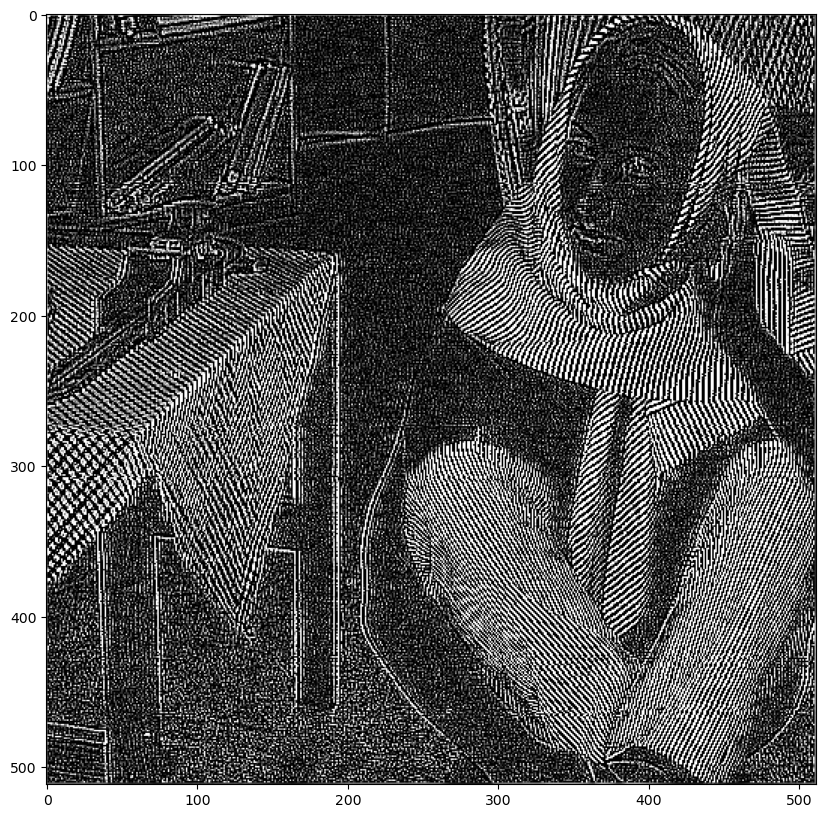

In [26]:
# Filters the images using FIND_EDGES filter
img_gray = img_gray.filter(ImageFilter.FIND_EDGES)
# Renders the filtered image
plt.figure(figsize=(10,10))
plt.imshow(img_gray ,cmap='gray')

Đoạn code này phát hiện và làm nổi bật các cạnh trong hình ảnh.

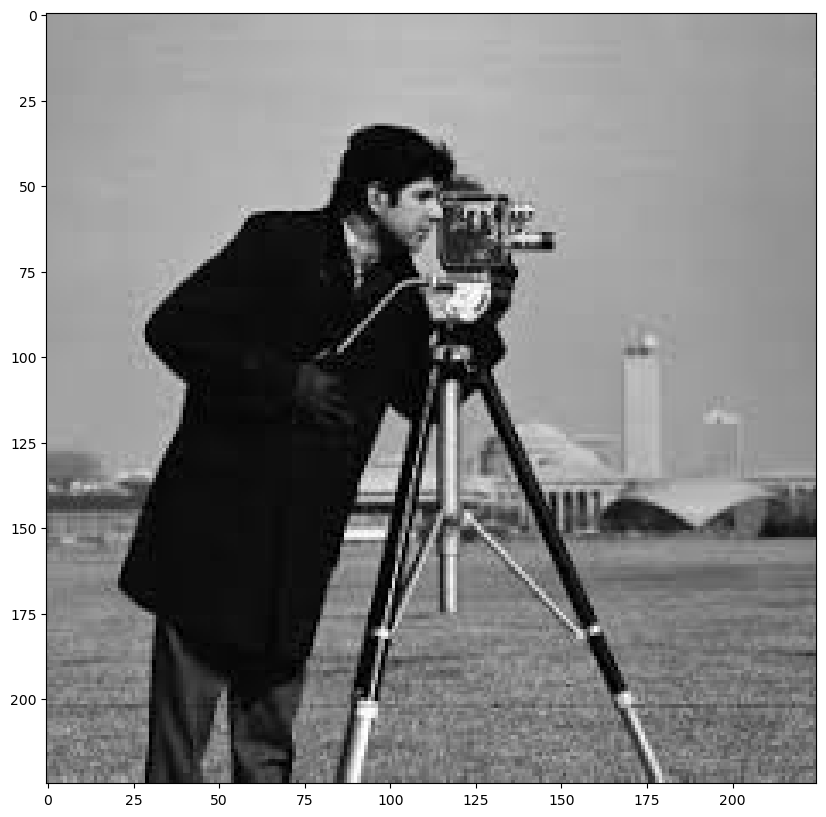

In [27]:
# Load the camera man image
image = Image.open("cameraman.jpeg")
# Make the image larger when it renders
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(image,cmap="gray")

Đoạn code này tải hình ảnh cameraman.jpeg và hiển thị nó.

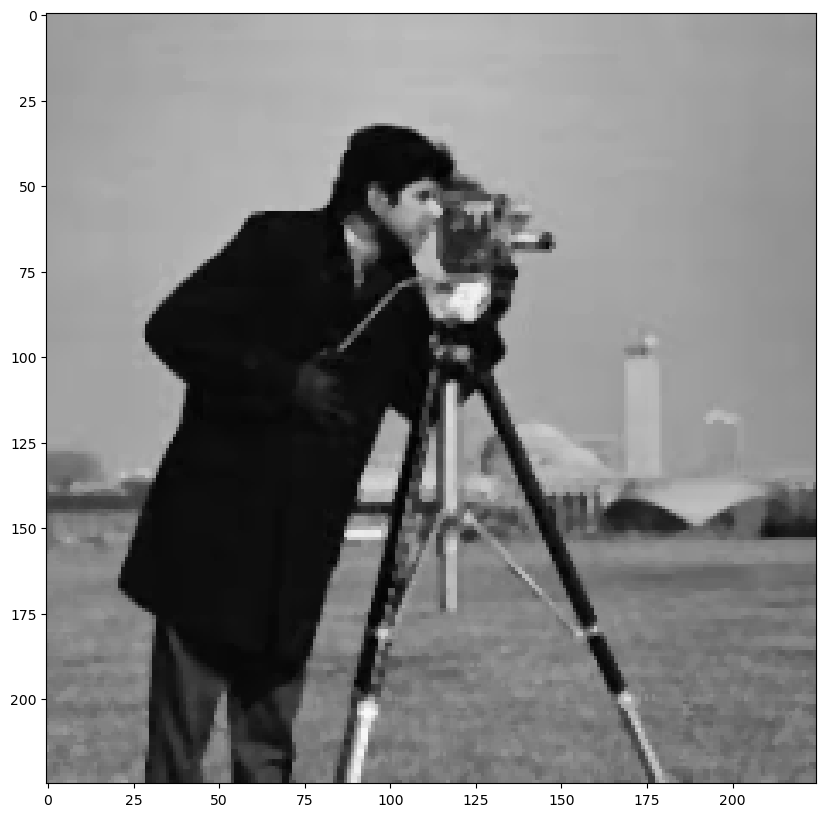

In [28]:
image = image.filter(ImageFilter.MedianFilter)
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(image,cmap="gray")

Đoạn code này áp dụng bộ lọc trung vị cho hình ảnh cameraman để làm mờ nền.